# Introdução à visualização de dados com Python 
## Explorando dados abertos de Lisboa
#### Monitorização de Parâmetros Ambientais da Cidade de Lisboa - Histórico 15/07/2021 a 15/01/2024

In [104]:
import pandas as pd

In [107]:
df = pd.read_csv("me2024s1.csv")
df.head()

,DTM_UTC,DTM_LOCAL,TEMATICA,COD_PARAMETRO,PARAMETRO,NR_ESTACAO,COD_SENSOR,LOCAL,LATITUDE,LONGITUDE,UNIDADE,ETIQUETA_NIVEL,COR_NIVEL,VALOR
0,2024-01-01 00:00:00.0,2024-01-01 00:00:00.0,ME,00HR,HR,1,ME00HR0001,Calçada da Ajuda,38.702631,-9.199692,%,@ NA,CINZENTO,79.3
1,2024-01-01 00:00:00.0,2024-01-01 00:00:00.0,ME,00HR,HR,3,ME00HR0003,Cais do Sodré,38.705264,-9.143603,%,@ NA,CINZENTO,81.9
2,2024-01-01 00:00:00.0,2024-01-01 00:00:00.0,ME,00HR,HR,5,ME00HR0005,Avenida Vinte e Quatro de Julho,38.706295,-9.156625,%,@ NA,CINZENTO,99.6
3,2024-01-01 00:00:00.0,2024-01-01 00:00:00.0,ME,00HR,HR,6,ME00HR0006,Avenida Infante Santo,38.707116,-9.167791,%,@ NA,CINZENTO,85.6
4,2024-01-01 00:00:00.0,2024-01-01 00:00:00.0,ME,00HR,HR,7,ME00HR0007,Santa Apolónia - Avenida Infante Dom Henrique,38.712710,-9.123679,%,@ NA,CINZENTO,74.3


In [108]:
df.dtypes

DTM_UTC            object
DTM_LOCAL          object
TEMATICA           object
COD_PARAMETRO      object
PARAMETRO          object
NR_ESTACAO          int64
COD_SENSOR         object
LOCAL              object
LATITUDE          float64
LONGITUDE         float64
UNIDADE            object
ETIQUETA_NIVEL     object
COR_NIVEL          object
VALOR             float64
dtype: object

In [109]:
df_temp = df[df["PARAMETRO"] == "TEMP"].copy()

In [110]:
df_temp["DTM_LOCAL"] = pd.to_datetime(df_temp["DTM_LOCAL"])

df_temp_day = df_temp[df_temp["DTM_LOCAL"].dt.date == pd.to_datetime("2024-01-01").date()]

In [111]:
media_local = df_temp_day.groupby("LOCAL")["VALOR"].mean()
media_local.sort_values()

LOCAL
Monsanto - Alameda Keil do Amaral                             -3.550000
Estrada de Monsanto                                            6.829167
Campo de Ourique                                               7.745833
Jardim Professor António Franco                                7.975000
Quinta das Conchas  - Avenida Maria Helena Vieira da Silva     8.012500
                                                                ...    
Rua Nau Catrineta cruz Rua Nova dos Mercadores                13.208333
Santa Apolónia - Avenida Infante Dom Henrique                 13.333333
Restauradores - Avenida da Liberdade                          13.391667
Avenida da Républica                                          13.576923
Cemitério dos Prazeres                                        14.679167
Name: VALOR, Length: 65, dtype: float64

<AxesSubplot: xlabel='LOCAL'>

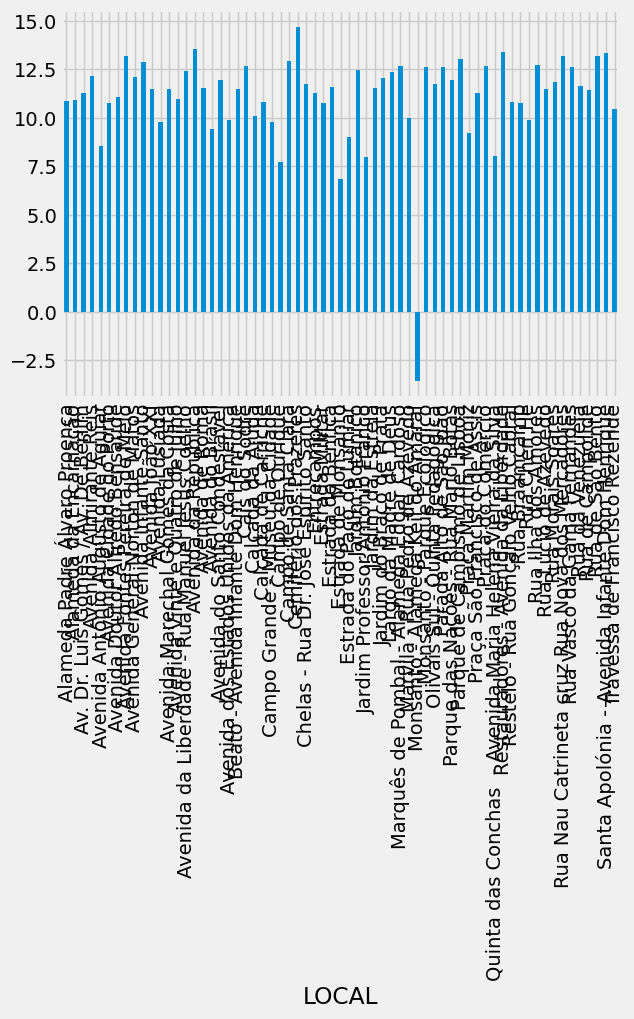

In [112]:
media_local.plot(kind="bar")

<AxesSubplot: ylabel='LOCAL'>

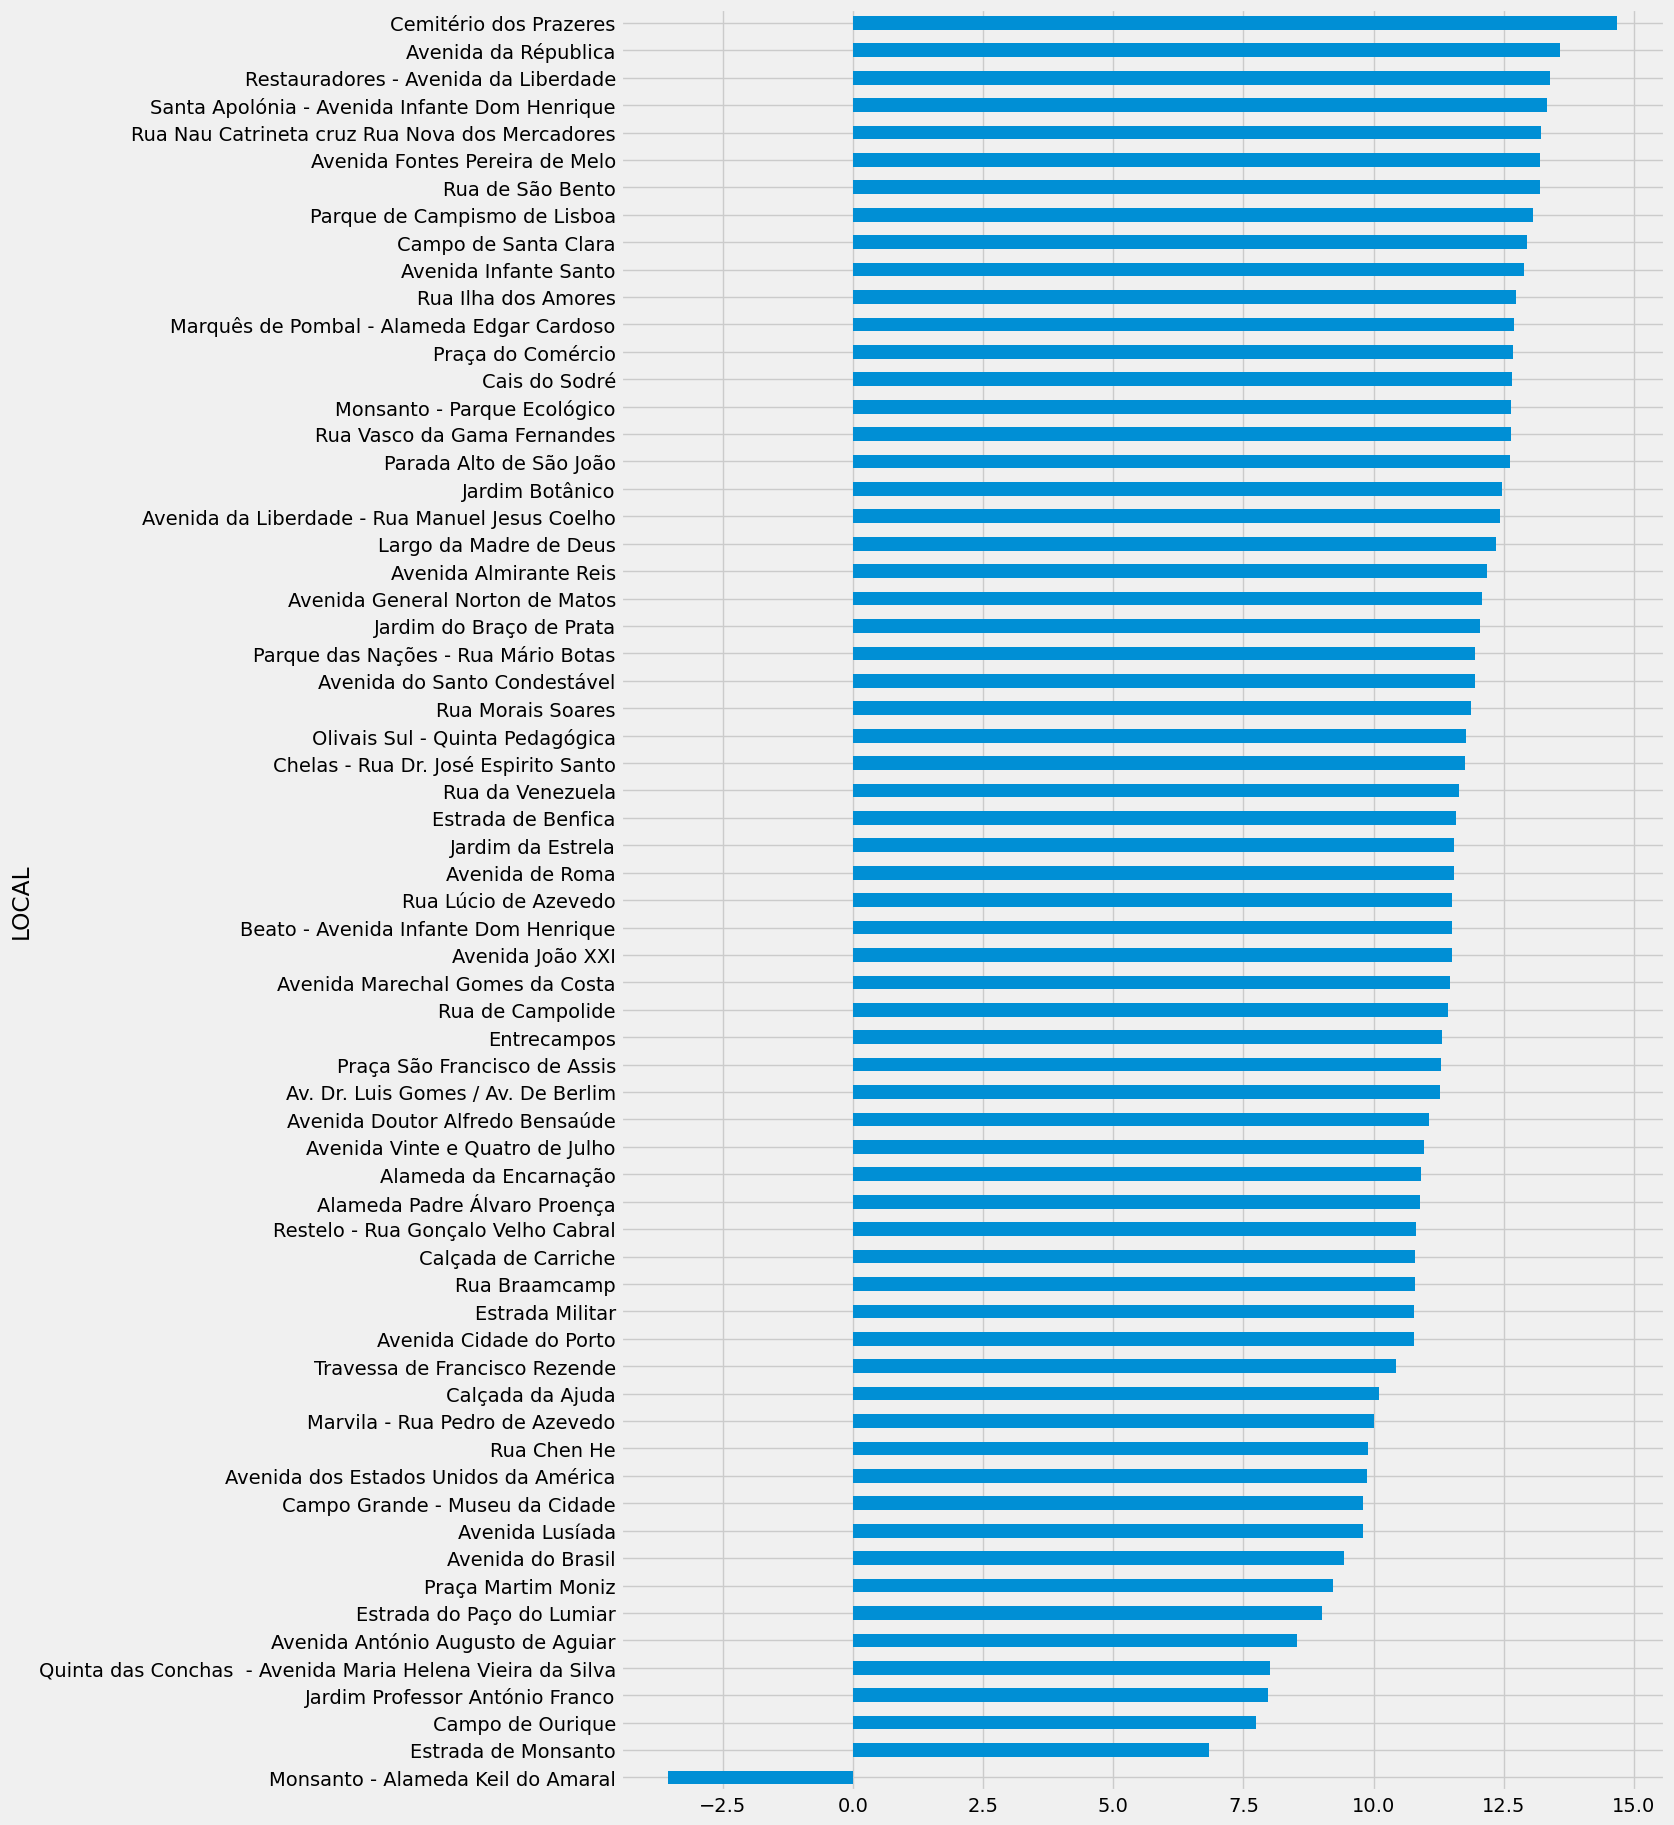

In [113]:
media_local.sort_values().plot(
    kind="barh",
    figsize=(12,22),
)

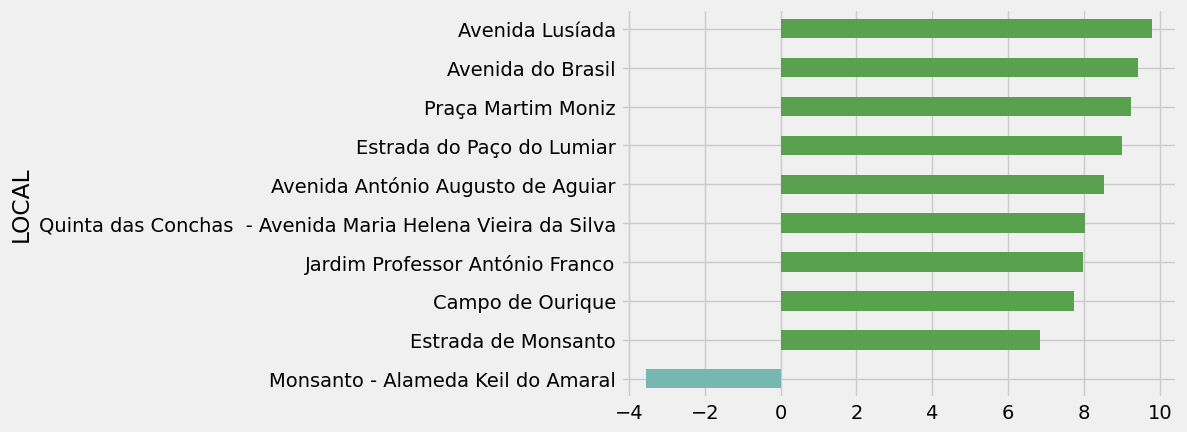

In [117]:
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")
plt.tight_layout()
ax = media_local.sort_values().head(10).plot(kind="barh", color = ["#76b7b2" if v < 0 else "#59a14f" for v in media_local.sort_values().head(10)])
#ax.set_ylabel("")
#ax.set_title("test")

#ax.set_facecolor("#f5f5f5")

In [114]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']